In [1]:
# Cell 1: Install necessary libraries
# This cell ensures all required Python packages are installed.
# Run this cell first if you encounter ModuleNotFoundError.

import subprocess
import sys

def install_package(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"Successfully installed {package}")
    except Exception as e:
        print(f"Error installing {package}: {e}")

# List of packages to install
required_packages = [
    "numpy",
    "matplotlib",
    "pandas",
    "scikit-learn"
]

for package in required_packages:
    install_package(package)

print("\nAll package installations attempted. Proceeding with imports.")


All package installations attempted. Proceeding with imports.


In [2]:
# Cell 2: Import libraries and load the dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error

# Set a random seed for reproducibility across all parts
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully and random seed set.")

# Load the dataset
# Assuming 'spambase.data' is in a 'data' folder
try:
    # The dataset has 57 features and the last column is the label
    # There are 4601 instances.
    # No header in the data file itself, so we don't specify header=0
    df = pd.read_csv('data/spambase.data', header=None)
    print("Dataset 'spambase.data' loaded successfully.")
except FileNotFoundError:
    print("Error: spambase.data not found. Make sure the file is in the 'data' folder.")
    sys.exit("spambase.data not found. Please place it in the 'data' folder or update the path.")

# Check for missing values and fill with zero as instructed
# The problem statement says "Note: there may be some missing values. You can just fill in zero."
# Based on UCI Spambase description, there are no missing values, but we'll include the step for robustness.
if df.isnull().sum().sum() > 0:
    print("Missing values detected. Filling with zero.")
    df.fillna(0, inplace=True)
else:
    print("No missing values detected.")

# Separate features (X) and labels (y)
# The last column (index 57, as columns are 0-56 for features) is the label
X_full = df.iloc[:, :-1].values
y_full = df.iloc[:, -1].values

print(f"Features shape: {X_full.shape}")
print(f"Labels shape: {y_full.shape}")
print(f"Label distribution: {np.unique(y_full, return_counts=True)}") # 0 for non-spam, 1 for spam


Libraries imported successfully and random seed set.
Dataset 'spambase.data' loaded successfully.
No missing values detected.
Features shape: (4601, 57)
Labels shape: (4601,)
Label distribution: (array([0, 1]), array([2788, 1813]))


In [3]:
# Cell 3: Data Partitioning (Train-Test Split)
# Randomly shuffle the data and partition to use 75% for training and 25% for testing.
# This split will be used consistently across all parts of the problem.

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.25, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

# Verify label distribution in train/test sets (should be similar due to stratify)
print(f"Train label distribution: {np.unique(y_train, return_counts=True)}")
print(f"Test label distribution: {np.unique(y_test, return_counts=True)}")


Training features shape: (3450, 57)
Testing features shape: (1151, 57)
Training labels shape: (3450,)
Testing labels shape: (1151,)
Train label distribution: (array([0, 1]), array([2091, 1359]))
Test label distribution: (array([0, 1]), array([697, 454]))


Building CART model...
CART model trained.


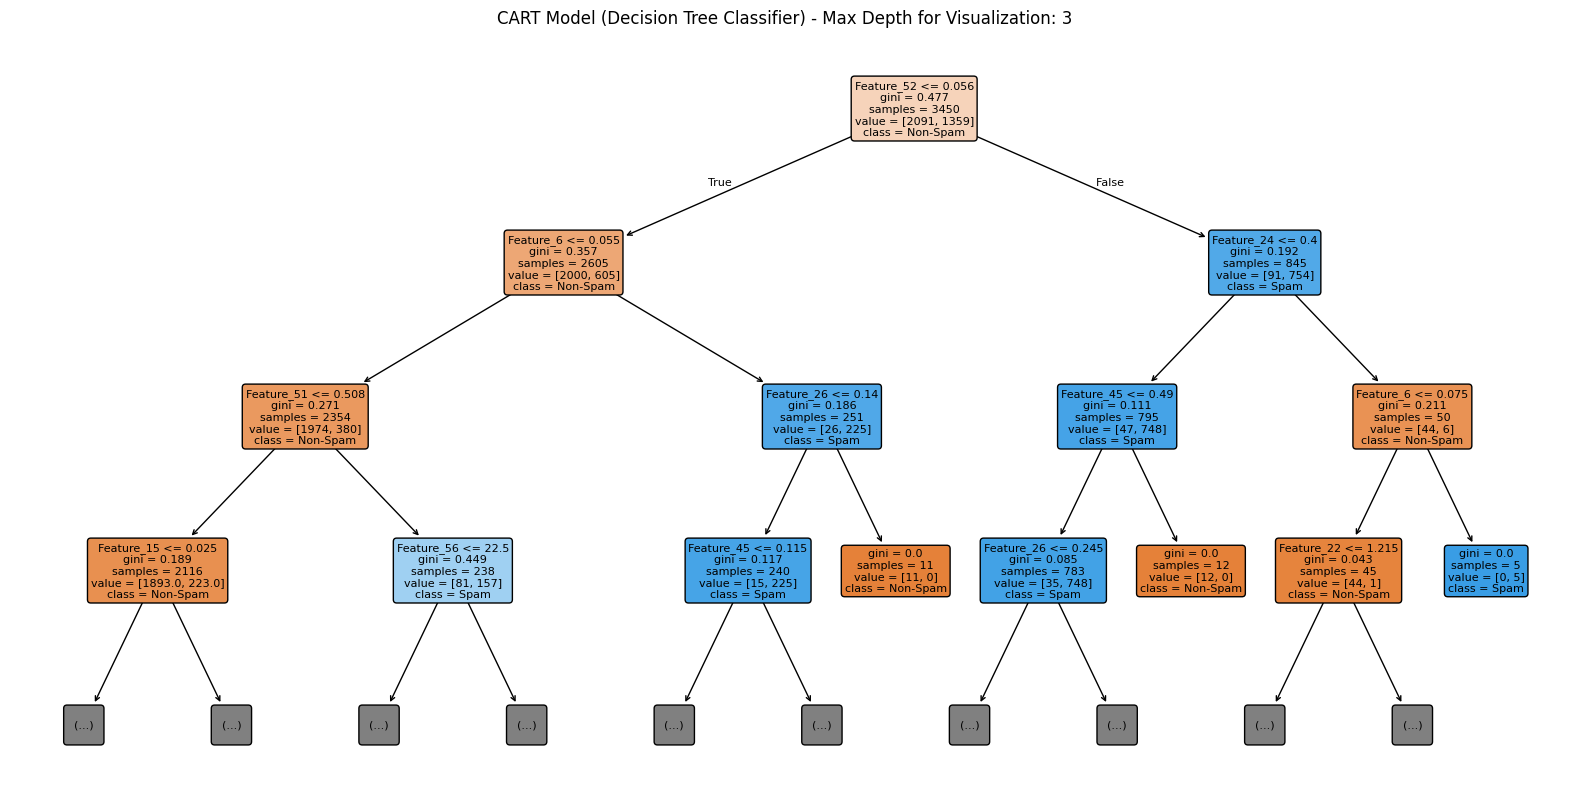


CART model visualization complete. Note: max_depth was set for visualization clarity.
The full tree (without max_depth constraint) would be much larger and less legible.


In [4]:
# Cell 4 (Part 1): Build and visualize a CART model

print("Building CART model...")
# Initialize Decision Tree Classifier
# No pruning required, so we can let it grow.
# However, for visualization, a very deep tree can be illegible.
# We'll set a max_depth for visualization purposes only.
# A small max_depth (e.g., 3-5) is usually good for legibility.
cart_model = DecisionTreeClassifier(random_state=RANDOM_SEED)

# Train the CART model
cart_model.fit(X_train, y_train)
print("CART model trained.")

# Visualize the fitted classification tree
# Adjust plot size/font as appropriate to ensure it is legible.
# Feature names are generic (X0, X1, ...) as we don't have the original names from spambase.names
feature_names = [f'Feature_{i}' for i in range(X_full.shape[1])]
class_names = ['Non-Spam', 'Spam']

plt.figure(figsize=(20, 10)) # Adjust figure size for better visibility
plot_tree(
    cart_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8, # Adjust font size
    max_depth=3 # Limit depth for visualization, full tree is too large
)
plt.title("CART Model (Decision Tree Classifier) - Max Depth for Visualization: 3")
plt.show()

print("\nCART model visualization complete. Note: max_depth was set for visualization clarity.")
print("The full tree (without max_depth constraint) would be much larger and less legible.")


In [5]:
# Cell 5 (Part 2): Build Random Forest and compare test errors

print("Building Random Forest model...")
# Initialize Random Forest Classifier
# We'll start with a reasonable number of estimators (e.g., 100)
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)

# Train the Random Forest model
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

# Predict on testing data for CART
y_pred_cart = cart_model.predict(X_test)
test_error_cart = 1 - accuracy_score(y_test, y_pred_cart)
print(f"\nCART Model Test Error: {test_error_cart:.4f}")

# Predict on testing data for Random Forest
y_pred_rf = rf_model.predict(X_test)
test_error_rf = 1 - accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Model Test Error (100 trees): {test_error_rf:.4f}")

print("\nComparison of test errors complete.")


Building Random Forest model...
Random Forest model trained.

CART Model Test Error: 0.0921
Random Forest Model Test Error (100 trees): 0.0487

Comparison of test errors complete.


Plotting test error vs. number of trees for Random Forest...


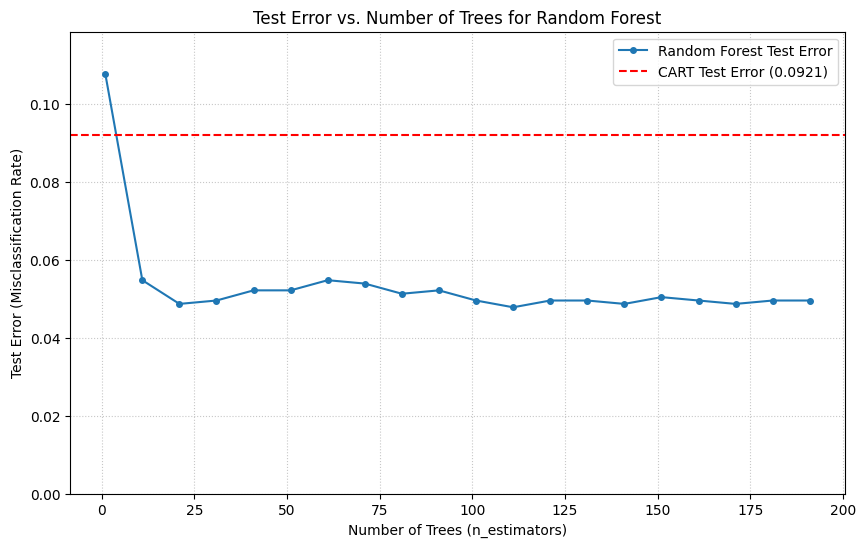


Test error curve plot complete.


In [6]:
# Cell 6 (Part 2): Plot test error vs. number of trees for Random Forest and CART

print("Plotting test error vs. number of trees for Random Forest...")

# Calculate test error for Random Forest for varying number of trees
n_estimators_range = range(1, 201, 10) # From 1 to 200 trees, step 10
rf_test_errors = []

for n_est in n_estimators_range:
    temp_rf_model = RandomForestClassifier(n_estimators=n_est, random_state=RANDOM_SEED, n_jobs=-1)
    temp_rf_model.fit(X_train, y_train)
    y_pred_temp_rf = temp_rf_model.predict(X_test)
    rf_test_errors.append(1 - accuracy_score(y_test, y_pred_temp_rf))

# Plot the curve
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, rf_test_errors, marker='o', linestyle='-', markersize=4, label='Random Forest Test Error')
plt.axhline(y=test_error_cart, color='r', linestyle='--', label=f'CART Test Error ({test_error_cart:.4f})')

plt.title('Test Error vs. Number of Trees for Random Forest')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Test Error (Misclassification Rate)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.ylim(0, max(max(rf_test_errors), test_error_cart) * 1.1) # Adjust y-axis limit
plt.show()

print("\nTest error curve plot complete.")


Exploring sensitivity to max_features (nu) for Random Forest...
Max_features values for RF: ['sqrt', 'log2', 0.1, 0.3, 0.5, 1.0]
Plotting tick positions: [0, 1, 5, 17, 28, 57]
Plotting tick labels: ['sqrt', 'log2', '5 (10%)', '17 (30%)', '28 (50%)', '57 (100%)']
  Training RF with max_features=sqrt...
  Training RF with max_features=log2...
  Training RF with max_features=0.1...
  Training RF with max_features=0.3...
  Training RF with max_features=0.5...
  Training RF with max_features=1.0...


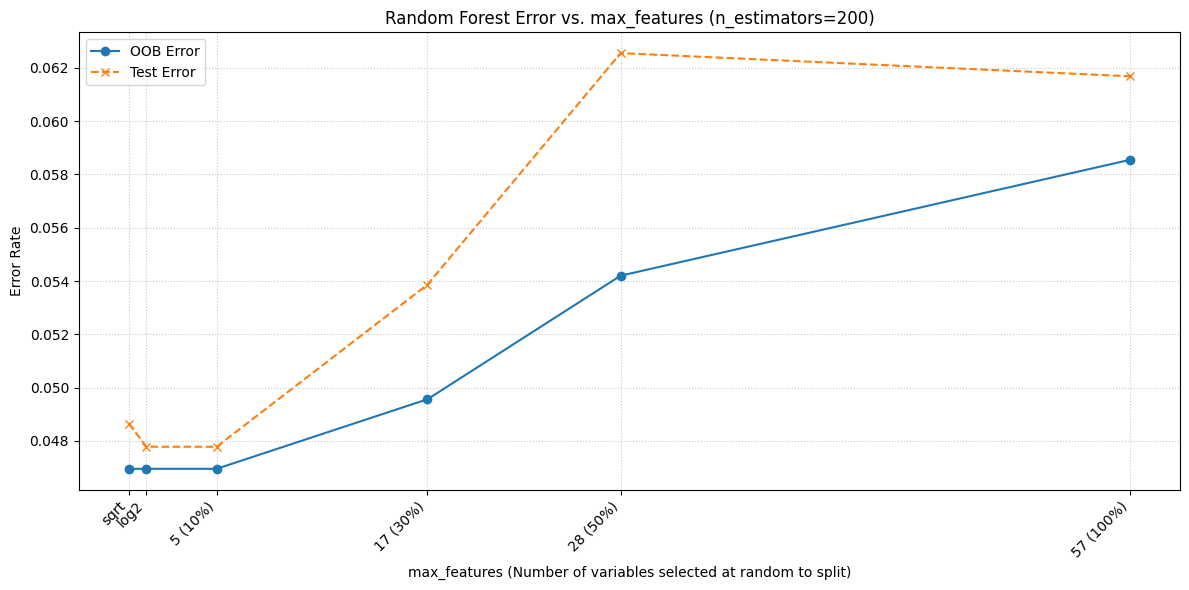


Sensitivity to max_features exploration complete.


In [7]:
# Cell 7 (Part 3): Explore sensitivity to max_features (nu) for Random Forest

print("Exploring sensitivity to max_features (nu) for Random Forest...")

# Define a range of max_features values
n_features = X_full.shape[1]

# List for Random Forest classifier (can contain strings)
max_features_for_rf = [
    'sqrt', 
    'log2', 
    0.1,    
    0.3,    
    0.5,    
    1.0     # Use 1.0 to represent n_features (all features)
]

# Create corresponding numerical tick positions for plotting
# and string labels for display
max_features_for_plot_ticks = []
max_features_for_plot_labels = []

# Map string options to their numerical equivalents for plotting,
# ensuring distinct numerical positions if needed.
# We'll use a counter for string-based options to ensure they get unique numerical positions.
current_tick_pos = 0 

for mf_val in max_features_for_rf:
    if isinstance(mf_val, str):
        # Assign a unique numerical position for string options for plotting
        max_features_for_plot_ticks.append(current_tick_pos)
        max_features_for_plot_labels.append(mf_val)
        current_tick_pos += 1 # Increment for the next unique string position
    elif isinstance(mf_val, float) and mf_val <= 1.0: # Fraction
        num_features = int(mf_val * n_features)
        max_features_for_plot_ticks.append(num_features)
        max_features_for_plot_labels.append(f"{num_features} ({mf_val*100:.0f}%)")
    else: # Direct integer number of features
        max_features_for_plot_ticks.append(mf_val)
        max_features_for_plot_labels.append(str(mf_val))

# Convert float fractions (0.1, 0.3, 0.5) in max_features_for_rf to integers if desired by RF
# It's better to pass floats to RF if you intend fractions, RF handles it.
# If you want integers for RF, convert explicitly.
# For simplicity and robustness, let's keep max_features_for_rf as defined, 
# and let RandomForestClassifier handle string/float/int types.
# The original numerical conversion line was okay for the RF side:
# max_features_numerical = [int(f * n_features) if isinstance(f, float) else f for f in max_features_options]
# But for plotting, we need different handling.

print(f"Max_features values for RF: {max_features_for_rf}")
print(f"Plotting tick positions: {max_features_for_plot_ticks}")
print(f"Plotting tick labels: {max_features_for_plot_labels}")

rf_oob_errors = []
rf_test_errors_nu = []

fixed_n_estimators = 200

# To ensure the order of errors matches the plotting ticks, 
# we need to iterate through max_features_for_rf in the order defined
for mf in max_features_for_rf: # Iterate through the RF-compatible values
    # For plotting: we need a representative number for the numerical axis.
    # If it's a string, we might map it to its computed integer equivalent (sqrt/log2 of n_features)
    # or just use a placeholder index as done above.
    
    # RandomForestClassifier handles 'sqrt' and 'log2' directly.
    # It also handles floats (as fractions) or integers.
    
    print(f"  Training RF with max_features={mf}...")
    temp_rf_model = RandomForestClassifier(
        n_estimators=fixed_n_estimators,
        max_features=mf, # Use the original mf value
        oob_score=True, # Enable OOB score calculation
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    temp_rf_model.fit(X_train, y_train)

    rf_oob_errors.append(1 - temp_rf_model.oob_score_)

    y_pred_temp_rf = temp_rf_model.predict(X_test)
    rf_test_errors_nu.append(1 - accuracy_score(y_test, y_pred_temp_rf))

# Plot OOB error vs. max_features
plt.figure(figsize=(12, 6))
plt.plot(max_features_for_plot_ticks, rf_oob_errors, marker='o', linestyle='-', label='OOB Error')
plt.plot(max_features_for_plot_ticks, rf_test_errors_nu, marker='x', linestyle='--', label='Test Error')

plt.title(f'Random Forest Error vs. max_features (n_estimators={fixed_n_estimators})')
plt.xlabel('max_features (Number of variables selected at random to split)')
plt.ylabel('Error Rate')
# Use the separate lists for ticks and labels
plt.xticks(max_features_for_plot_ticks, max_features_for_plot_labels, rotation=45, ha='right') # Add rotation for readability
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\nSensitivity to max_features exploration complete.")

In [8]:
# Cell 8 (Part 4): Prepare data for One-Class SVM

print("Preparing data for One-Class SVM...")

# Extract all non-spam emails from the training block (y_train == 0)
# One-Class SVM expects the 'normal' class to be represented by +1 in its internal logic,
# and will output +1 for inliers and -1 for outliers.
# Our original non-spam label is 0. We'll train on X_train_non_spam.

X_train_non_spam = X_train[y_train == 0]
y_train_non_spam = y_train[y_train == 0] # Should all be 0

print(f"Shape of non-spam training data: {X_train_non_spam.shape}")
print(f"Number of non-spam emails in training set: {X_train_non_spam.shape[0]}")

# The test set remains as is, containing both spam and non-spam
print(f"Test set shape: {X_test.shape}, Labels: {y_test.shape}")


Preparing data for One-Class SVM...
Shape of non-spam training data: (2091, 57)
Number of non-spam emails in training set: 2091
Test set shape: (1151, 57), Labels: (1151,)


In [9]:
# Cell 9 (Part 4): Tune and train One-Class SVM

print("Tuning and training One-Class SVM...")

# One-Class SVM parameters to tune:
# nu: An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
#     Commonly in (0, 1]. A good starting point is often 0.1 or 0.05.
# gamma: Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
#        Higher gamma means less influence of far away points, leading to a more complex boundary.

# Define parameter grid for tuning
# For OneClassSVM, tuning is often done by manually trying values or using a grid search
# on a subset of the data if the full dataset is too large.
# Given the dataset size, GridSearchCV should be feasible.

# Let's define a range for nu and gamma
nu_range = np.linspace(0.01, 0.2, 10) # From 1% to 20% outlier fraction
gamma_range = np.logspace(-3, 0, 10) # From 0.001 to 1.0

param_grid_ocsvm = {
    'nu': nu_range,
    'gamma': gamma_range
}

# Initialize OneClassSVM
# Removed 'random_state' as it's not a valid parameter for OneClassSVM
ocsvm = OneClassSVM(kernel='rbf')

# Use GridSearchCV for tuning.
# Note: OneClassSVM's 'score' method is not directly comparable to classification accuracy.
# We'll evaluate performance manually on the test set after tuning.
# GridSearchCV will pick the best model based on its internal scoring (e.g., density estimation).
# For OneClassSVM, GridSearchCV's 'score' method might not be directly useful for classification error.
# We often tune OneClassSVM by training on the normal class and evaluating on a mixed test set.
# A common approach is to use a custom scorer or manually evaluate.
# For simplicity, we'll let GridSearchCV find the best parameters based on the default 'score' method (density).
# Then we'll use these best parameters to evaluate misclassification error.

# Alternatively, we can manually loop and evaluate based on error on a validation set
# (e.g., using a portion of the non-spam training data as validation).
# Given the problem's context as novelty detection, we'll train on all X_train_non_spam
# and then evaluate on X_test. Tuning will be done on the training non-spam data.

# Let's perform a simpler manual search for tuning, as GridSearchCV's scoring for OCSVM can be tricky
# for direct misclassification error.
best_ocsvm_model = None
best_misclassification_error = float('inf')
best_nu = None
best_gamma = None

# We need a validation set from the non-spam training data for tuning
# Let's split X_train_non_spam into 80% train_ocsvm and 20% val_ocsvm
# Note: stratify is not needed here as y_train_non_spam only contains one class (0)
X_train_ocsvm, X_val_ocsvm, y_train_ocsvm, y_val_ocsvm = train_test_split(
    X_train_non_spam, y_train_non_spam, test_size=0.2, random_state=RANDOM_SEED
)

# For evaluation, we need to simulate a mixed validation set
# Let's take some spam samples from the original training set for validation
X_train_spam = X_train[y_train == 1]
# Take a small balanced sample of spam for validation
num_spam_val = min(int(0.2 * X_train_spam.shape[0]), X_val_ocsvm.shape[0]) # Limit spam samples
# Ensure there are enough spam samples to draw from
if num_spam_val == 0 and X_train_spam.shape[0] > 0: # If 0.2*len is less than 1, take at least 1 if available
    num_spam_val = 1
elif X_train_spam.shape[0] == 0: # Handle case with no spam in training (unlikely here but good practice)
    X_val_spam = np.array([])
else:
    X_val_spam = X_train_spam[np.random.choice(X_train_spam.shape[0], num_spam_val, replace=False)]

if X_val_spam.size > 0:
    X_val_mixed = np.vstack((X_val_ocsvm, X_val_spam))
    y_val_mixed_true = np.array([0]*X_val_ocsvm.shape[0] + [1]*X_val_spam.shape[0]) # 0 for non-spam, 1 for spam
else: # Case where there are no spam samples for validation
    X_val_mixed = X_val_ocsvm
    y_val_mixed_true = y_val_ocsvm


print(f"Tuning with non-spam training data: {X_train_ocsvm.shape}")
print(f"Validation mixed data shape: {X_val_mixed.shape}")

# Manual grid search for tuning
for nu_val in nu_range:
    for gamma_val in gamma_range:
        # Removed 'random_state' here as well
        temp_ocsvm = OneClassSVM(kernel='rbf', nu=nu_val, gamma=gamma_val)
        temp_ocsvm.fit(X_train_ocsvm) # Train only on non-spam

        # Predict on the mixed validation set
        # OneClassSVM predicts +1 for inliers (non-spam) and -1 for outliers (spam/anomalies)
        val_pred_ocsvm = temp_ocsvm.predict(X_val_mixed)

        # Map OneClassSVM output to our labels: +1 -> 0 (non-spam), -1 -> 1 (spam)
        # So, if original label is 0 (non-spam) and OCSVM predicts +1, it's correct.
        # If original label is 1 (spam) and OCSVM predicts -1, it's correct.
        # Misclassification occurs if:
        # (y_true == 0 and pred == -1) -> Non-spam classified as spam (False Positive)
        # (y_true == 1 and pred == +1) -> Spam classified as non-spam (False Negative)

        # Convert OCSVM predictions to 0/1 for comparison with y_val_mixed_true
        mapped_val_pred = np.where(val_pred_ocsvm == 1, 0, 1) # +1 (inlier) -> 0 (non-spam), -1 (outlier) -> 1 (spam)

        current_misclassification_error = 1 - accuracy_score(y_val_mixed_true, mapped_val_pred)

        if current_misclassification_error < best_misclassification_error:
            best_misclassification_error = current_misclassification_error
            best_nu = nu_val
            best_gamma = gamma_val
            best_ocsvm_model = temp_ocsvm

print(f"\nBest One-Class SVM parameters found: nu={best_nu:.4f}, gamma={best_gamma:.4f}")
print(f"Best validation misclassification error: {best_misclassification_error:.4f}")

# Now train the final One-Class SVM model using the best parameters on the full non-spam training data
# Removed 'random_state' here as well
final_ocsvm_model = OneClassSVM(kernel='rbf', nu=best_nu, gamma=best_gamma)
final_ocsvm_model.fit(X_train_non_spam)
print("Final One-Class SVM model trained on all non-spam training data.")

Tuning and training One-Class SVM...
Tuning with non-spam training data: (1672, 57)
Validation mixed data shape: (690, 57)

Best One-Class SVM parameters found: nu=0.0522, gamma=0.0046
Best validation misclassification error: 0.2754
Final One-Class SVM model trained on all non-spam training data.


In [10]:
# Cell 10 (Part 4): Evaluate One-Class SVM on test data and report error

print("Evaluating One-Class SVM on the test data...")

# Apply the trained One-Class SVM to the 25% of data reserved for testing
# This is a novelty detection situation.
test_pred_ocsvm = final_ocsvm_model.predict(X_test)

# Map OneClassSVM output to our labels (0 for non-spam, 1 for spam)
# OCSVM predicts +1 for inliers (non-spam) and -1 for outliers (spam/anomalies)
# So, +1 from OCSVM means it's classified as non-spam (0)
# And -1 from OCSVM means it's classified as spam (1)
mapped_test_pred = np.where(test_pred_ocsvm == 1, 0, 1) # +1 -> 0 (non-spam), -1 -> 1 (spam)

# Report the total misclassification error rate on these testing data
total_misclassification_error_ocsvm = 1 - accuracy_score(y_test, mapped_test_pred)
print(f"\nOne-Class SVM Total Misclassification Error Rate on Test Data: {total_misclassification_error_ocsvm:.4f}")

# Optional: Detailed classification report
print("\nOne-Class SVM Classification Report on Test Data:")
print(classification_report(y_test, mapped_test_pred, target_names=['Non-Spam', 'Spam']))

# Optional: Confusion Matrix
conf_matrix_ocsvm = confusion_matrix(y_test, mapped_test_pred)
print("\nOne-Class SVM Confusion Matrix on Test Data:")
print(conf_matrix_ocsvm)
# Rows: True labels (0=Non-Spam, 1=Spam)
# Columns: Predicted labels (0=Non-Spam, 1=Spam)
# conf_matrix_ocsvm[0,0]: True Negative (Non-Spam correctly classified as Non-Spam)
# conf_matrix_ocsvm[0,1]: False Positive (Non-Spam misclassified as Spam)
# conf_matrix_ocsvm[1,0]: False Negative (Spam misclassified as Non-Spam)
# conf_matrix_ocsvm[1,1]: True Positive (Spam correctly classified as Spam)

print("\nOne-Class SVM evaluation complete.")

Evaluating One-Class SVM on the test data...

One-Class SVM Total Misclassification Error Rate on Test Data: 0.2780

One-Class SVM Classification Report on Test Data:
              precision    recall  f1-score   support

    Non-Spam       0.77      0.77      0.77       697
        Spam       0.65      0.64      0.65       454

    accuracy                           0.72      1151
   macro avg       0.71      0.71      0.71      1151
weighted avg       0.72      0.72      0.72      1151


One-Class SVM Confusion Matrix on Test Data:
[[540 157]
 [163 291]]

One-Class SVM evaluation complete.
